# Image Retrieval on CIFAR-100

Given a **query image** and **K**, returns the **K most similar images** from the CIFAR-100 database with their labels.

**Pipeline:**
1. Load a pre-trained ViT/Swin/GCViT model
2. Extract the feature vector of the query image
3. Compute cosine similarity against the entire database
4. Return the K images with the highest similarity scores

## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import timm
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torch.nn import CosineSimilarity

# ── Configuration ─────────────────────────────────────────────────────────────

# Model name: vit_s16 | swin_s | gcvit_s
MODEL_NAME = "vit_s16"

TIMM_MODELS = {
    "vit_s16": "vit_small_patch16_224.augreg_in1k",
    "swin_s":  "swin_small_patch4_window7_224.ms_in1k",
    "gcvit_s": "gcvit_small.in1k",
}
MODEL_TIMM = TIMM_MODELS[MODEL_NAME]

# Path to pre-extracted database features (pickle file from extract_features.py)
FEATURES_DIR     = "./cifar100_features"
DB_FEATURES_PATH = os.path.join(FEATURES_DIR, f"{MODEL_NAME}_cifar100_train.pkl")

DATASET_ROOT = "../datasets/CIFAR-100"

# Must match the weights used when running extract_features.py.
# None → ImageNet pretrained; Path → fine-tuned checkpoint
WEIGHTS = "./model_save/vit_s16_cifar100.pth"

# CIFAR-100 fine-grained class labels (100 classes, alphabetical order)
CLASSES = (
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Model:  {MODEL_NAME} ({MODEL_TIMM})")
print(f"DB features path: {DB_FEATURES_PATH}")
print(f"Weights: {WEIGHTS if WEIGHTS else 'ImageNet pretrained (None)'}")

/home/sotatek/anaconda3/envs/train_ir/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Model:  vit_s16 (vit_small_patch16_224.augreg_in1k)
DB features path: ./cifar100_features/vit_s16_cifar100_train.pkl
Weights: ./model_save/vit_s16_cifar100.pth


## 2. Load Model & Database Features

In [2]:
if WEIGHTS and not os.path.exists(WEIGHTS):
    raise FileNotFoundError(
        f"Weights file not found: {WEIGHTS}\n"
        "Check the path or set WEIGHTS = None to use ImageNet pretrained weights."
    )

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"GPU VRAM: {free_mem/1024**3:.1f} GB free / {total_mem/1024**3:.1f} GB total")

print(f"Loading model with weights: {WEIGHTS if WEIGHTS else 'ImageNet pretrained'}")
if WEIGHTS:
    model = timm.create_model(MODEL_TIMM, num_classes=0, checkpoint_path=WEIGHTS)
else:
    model = timm.create_model(MODEL_TIMM, pretrained=True, num_classes=0)
model.eval()

# Fall back to CPU if GPU is out of memory
try:
    model.to(device)
    compute_device = device
    print(f"Model loaded on: {compute_device}")
except RuntimeError as e:
    if "out of memory" in str(e).lower() or "AcceleratorError" in str(type(e).__name__):
        torch.cuda.empty_cache()
        compute_device = torch.device("cpu")
        model.to(compute_device)
        print(f"CUDA OOM — falling back to CPU. Model loaded on: {compute_device}")
    else:
        raise

transform = timm.data.create_transform(
    **timm.data.resolve_data_config(model.pretrained_cfg)
)
print(f"Transform: {transform.transforms[0]}, {transform.transforms[1]}, ...")

print("\nLoading database features...")
if not os.path.exists(DB_FEATURES_PATH):
    raise FileNotFoundError(
        f"Features file not found: {DB_FEATURES_PATH}\n"
        f"Run extract_features.py first:  python extract_features.py --model {MODEL_NAME}"
    )

db_df     = pd.read_pickle(DB_FEATURES_PATH)
db_matrix = torch.tensor(
    np.array(db_df[MODEL_NAME].tolist()), dtype=torch.float32
).to(compute_device)                            # [N, D]
db_labels = db_df["labels"].values.astype(int)  # [N]
print(f"Database: {len(db_df):,} images | feature dim: {db_matrix.shape[1]}")

print("\nLoading CIFAR-100 train images...")
cifar100_train = torchvision.datasets.CIFAR100(root=DATASET_ROOT, train=True, download=True)
print(f"CIFAR-100 train: {len(cifar100_train):,} images | {len(CLASSES)} classes")
print("\nReady!")

GPU VRAM: 2.8 GB free / 23.5 GB total
Loading model with weights: ./model_save/vit_s16_cifar100.pth
Model loaded on: cuda
Transform: Resize(size=248, interpolation=bicubic, max_size=None, antialias=True), CenterCrop(size=(224, 224)), ...

Loading database features...
Database: 50,000 images | feature dim: 384

Loading CIFAR-100 train images...


/home/sotatek/anaconda3/envs/train_ir/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-100 train: 50,000 images | 100 classes

Ready!


## 3. Feature Extraction & Retrieval Functions

In [3]:
def encode_image(pil_image: Image.Image) -> torch.Tensor:
    """Extract a feature vector from a PIL image."""
    img_tensor = transform(pil_image).unsqueeze(0).to(compute_device)  # [1, C, H, W]
    with torch.no_grad():
        feat = model(img_tensor)  # [1, D]
    return feat.squeeze(0)  # [D]


def retrieve_top_k(
    query_image: Image.Image,
    k: int,
    db_matrix: torch.Tensor,
    db_labels: np.ndarray,
    cifar_dataset,
) -> dict:
    """
    Find the K most similar images to query_image in the CIFAR-100 database.

    Args:
        query_image  : query image (PIL.Image)
        k            : number of results to return
        db_matrix    : database feature matrix [N, D]
        db_labels    : corresponding integer labels [N]
        cifar_dataset: torchvision CIFAR100 dataset (for retrieving original images)

    Returns:
        dict with keys: scores, indices, labels, class_names, images
    """
    query_feat = encode_image(query_image)  # [D]

    cos_sim = CosineSimilarity(dim=1)
    scores  = cos_sim(db_matrix, query_feat.unsqueeze(0))  # [N]

    topk_scores, topk_indices = torch.topk(scores, k=k)
    topk_indices = topk_indices.cpu().numpy()
    topk_scores  = topk_scores.cpu().numpy()

    topk_labels     = db_labels[topk_indices]
    topk_classnames = [CLASSES[lbl] for lbl in topk_labels]
    topk_images     = [cifar_dataset[idx][0] for idx in topk_indices]

    return {
        "scores"     : topk_scores,
        "indices"    : topk_indices,
        "labels"     : topk_labels,
        "class_names": topk_classnames,
        "images"     : topk_images,
    }


def display_results(
    query_image: Image.Image,
    results: dict,
    query_label: int = None,
    figsize_per_img: float = 2.0,
):
    """
    Display the query image alongside the K retrieved results.
    Green border = correct label, red border = wrong label (only when query_label is known).
    """
    k     = len(results["images"])
    ncols = k + 1
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * figsize_per_img, figsize_per_img * 1.6))

    ax = axes[0]
    ax.imshow(query_image)
    title = "QUERY"
    if query_label is not None:
        title += f"\n({CLASSES[query_label]})"
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor("blue")
        spine.set_linewidth(3)
        spine.set_visible(True)

    for i, (img, lbl, cls, score) in enumerate(
        zip(results["images"], results["labels"], results["class_names"], results["scores"])
    ):
        ax = axes[i + 1]
        ax.imshow(img)
        ax.set_title(f"#{i+1} {cls}\n{score:.3f}", fontsize=7)
        ax.axis("off")
        if query_label is not None:
            color = "green" if lbl == query_label else "red"
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)
                spine.set_visible(True)

    if query_label is not None:
        patches = [
            mpatches.Patch(color="green", label="Correct label"),
            mpatches.Patch(color="red",   label="Wrong label"),
        ]
        fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=8,
                   bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f"Top-{k} retrieval  |  model: {MODEL_NAME}", fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()

print("Retrieval functions ready.")

Retrieval functions ready.


## 4. Query Image & K Selection

Two ways to provide a query image:
- **Option A**: Sample from the CIFAR-100 test set (label is known → colored borders shown)
- **Option B**: Load any image from a file path

Query image: /home/sotatek/Documents/Image_Retrieval/image-retrieval-using-transformers/CIFAR100/lion1.jpg


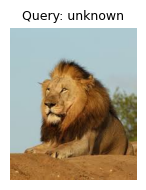

K = 10


In [4]:
# ── Input Parameters ──────────────────────────────────────────────────────────

K = 10  # Number of retrieved images

# Option A: sample from CIFAR-100 test set (True) or use a custom image (False)
USE_CIFAR_QUERY = False
QUERY_INDEX     = None  # None = random, or set an integer 0–9999

# Option B: path to a custom image (PNG/JPG/...)
CUSTOM_IMAGE_PATH = "/home/sotatek/Documents/Image_Retrieval/image-retrieval-using-transformers/CIFAR100/lion1.jpg"

# ──────────────────────────────────────────────────────────────────────────────

import random

if USE_CIFAR_QUERY:
    cifar100_test = torchvision.datasets.CIFAR100(root=DATASET_ROOT, train=False, download=True)
    if QUERY_INDEX is None:
        QUERY_INDEX = random.randint(0, len(cifar100_test) - 1)
        print(f"Randomly selected index: {QUERY_INDEX}")
    query_pil, query_label_int = cifar100_test[QUERY_INDEX]
    query_class = CLASSES[query_label_int]
    print(f"Query image: CIFAR-100 test[{QUERY_INDEX}]  |  label: {query_class} ({query_label_int})")
else:
    query_pil       = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")
    query_label_int = None
    query_class     = "unknown"
    print(f"Query image: {CUSTOM_IMAGE_PATH}")

plt.figure(figsize=(2, 2))
plt.imshow(query_pil)
plt.title(f"Query: {query_class}", fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"K = {K}")

## 5. Retrieval & Results

In [5]:
import time

t0 = time.time()
results = retrieve_top_k(
    query_image   = query_pil,
    k             = K,
    db_matrix     = db_matrix,
    db_labels     = db_labels,
    cifar_dataset = cifar100_train,
)
elapsed = time.time() - t0
print(f"Retrieval completed in {elapsed*1000:.1f} ms\n")

print(f"{'Rank':<6} {'DB Index':<10} {'Label':<8} {'Class':<18} {'Cosine Sim':<12}")
print("-" * 58)
for rank, (idx, lbl, cls, score) in enumerate(
    zip(results["indices"], results["labels"], results["class_names"], results["scores"]), 1
):
    marker = "✓" if (query_label_int is not None and lbl == query_label_int) else " "
    print(f"{rank:<6} {idx:<10} {lbl:<8} {cls:<18} {score:.4f}  {marker}")

if query_label_int is not None:
    n_correct = sum(lbl == query_label_int for lbl in results["labels"])
    print(f"\nCorrect labels: {n_correct}/{K}  ({n_correct/K*100:.0f}%)")

Retrieval completed in 258.2 ms

Rank   DB Index   Label    Class              Cosine Sim  
----------------------------------------------------------
1      26369      43       lion               0.9318   
2      6450       43       lion               0.9316   
3      25355      43       lion               0.9305   
4      37436      43       lion               0.9304   
5      45266      43       lion               0.9288   
6      42850      43       lion               0.9275   
7      42709      43       lion               0.9245   
8      41991      43       lion               0.9241   
9      11565      43       lion               0.9238   
10     21100      43       lion               0.9236   


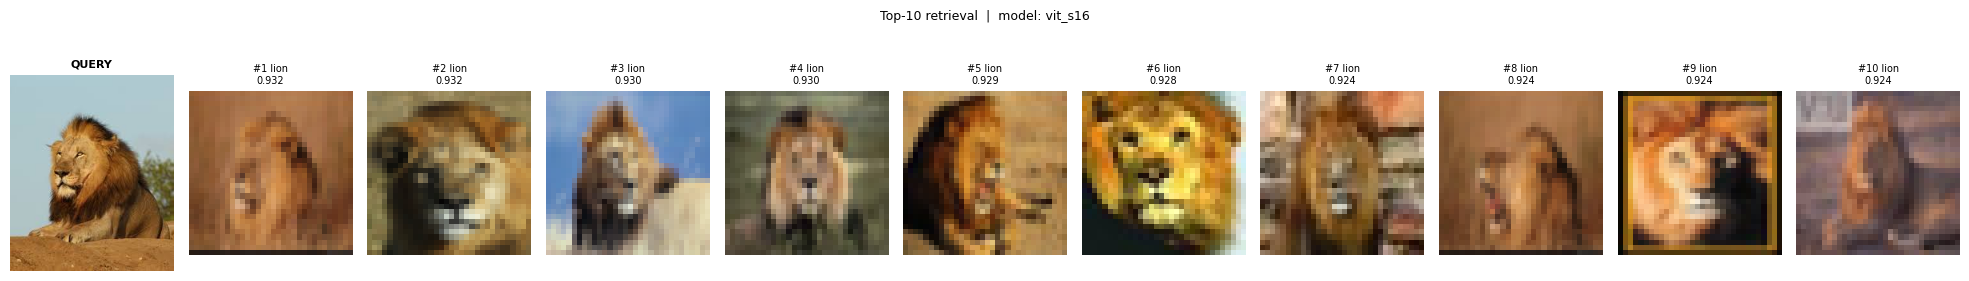

In [6]:
display_results(
    query_image     = query_pil,
    results         = results,
    query_label     = query_label_int,
    figsize_per_img = 1.8,
)